# Linear Plots ORAS5
## 21.01.26

The aim of this notebook is to identify long-term trends in a small number of ORAS5 ocean variables that could later be used as inputs to a machine learning model.

At the moment, only data from 1958–1970 is available locally. However, all of the code written here is designed to scale directly to the full ORAS5 record (1958–2025) once the remaining data is downloaded.

The general approach is as follows:
- Extract regional mean time series from the raw ORAS5 NetCDF files
- Compare trends using different time definitions (all months, same month each year, same season each year)
- Quantify how strong and consistent each trend is
- Rank the results to find the most promising variable–region–timescale combinations

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import linregress


## 1. Setup

In the cell below I specify the directory containing the boxed ORAS5 NetCDF files, a mapping between variable names and their ORAS5 file tokens, the geographic regions used in the analysis and a filename pattern used to extract timestamps (keeping this information in one place makes it easier to modify later)

In [2]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")  # change if needed

VARIABLE_TOKENS = {
    "sst": "sst",
    "salinity": "so_salinity",
    "u": "u_zonal",
    "v": "v_meridional",
    "thetao": "thetao_potential_temperature",
    "qnet": "net_downward_heat_flux",
}

REGIONS = {
    "UK_coast": dict(lat_min=48, lat_max=62, lon_min=-12, lon_max=4),
    "Subpolar_Gyre": dict(lat_min=50, lat_max=65, lon_min=-45, lon_max=-10),
    "Subtropical_NA": dict(lat_min=25, lat_max=40, lon_min=-60, lon_max=-20),
    "North_Atlantic": dict(lat_min=0, lat_max=90, lon_min=-80, lon_max=2),
}

# ORAS5_YYYY_MM_token_boxed.nc
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

DEPTH_MODE = {
    "sst": None,
    "salinity": "0_100m",
    "u": "0_100m",
    "v": "0_100m",
    "thetao": "0_100m",
    "qnet": None,
}

REGION_NAMES = list(REGIONS.keys())


I then defined a set of functions for:
- Extracting timestamps from filenames
- Identifying the main data variable inside a NetCDF file
- Dealing with longitude wrapping
- Guessing latitude and longitude coordinate names


In [3]:
def time_from_name(path: Path) -> np.datetime64:
    m = FILE_RE.match(path.name)
    if not m:
        raise ValueError(f"Filename didn't match pattern: {path.name}")
    y = int(m.group(1))
    mo = int(m.group(2))
    return np.datetime64(f"{y:04d}-{mo:02d}-01", "ns")

def infer_data_var(ds: xr.Dataset) -> str:
    dvs = list(ds.data_vars)
    if len(dvs) == 1:
        return dvs[0]
    # choose largest variable if multiple
    return max(dvs, key=lambda v: ds[v].size)

def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

def guess_lat_lon_names(obj) -> tuple[str | None, str | None]:
    names = list(obj.coords)
    lat = next((c for c in names if "lat" in c.lower()), None)
    lon = next((c for c in names if "lon" in c.lower()), None)
    return lat, lon

def guess_depth_name(da: xr.DataArray) -> str | None:
    for cand in ["depth", "deptht", "lev", "z"]:
        if cand in da.dims or cand in da.coords:
            return cand
    return None

def guess_spatial_dims(da: xr.DataArray, lat, lon) -> list[str]:
    """
    Works for:
      - curvilinear (nav_lat/nav_lon): dims often ('y','x')
      - regular: dims might be ('lat','lon') or ('latitude','longitude')
    """
    dims = list(da.dims)
    spatial = []
    # if lat/lon are DataArrays with dims, use those dims
    for d in getattr(lat, "dims", ()):
        if d in dims and d not in spatial:
            spatial.append(d)
    for d in getattr(lon, "dims", ()):
        if d in dims and d not in spatial:
            spatial.append(d)
    # fallback common names just in case
    for d in ["y", "x", "lat", "lon", "latitude", "longitude"]:
        if d in dims and d not in spatial:
            spatial.append(d)
    return spatial


I then define a function to extract a regional mean from a single ORAS5 NetCDF file which:
- Selects the correct variable
- Averages top 100m depth (unless 2d vaariable)
- Applies a latitude/longitude mask for the chosen region
- Computes a spatial mean

Important: this is done file-by-file rather than loading an entire multi-decade dataset into memory (which causes memory errors)


In [4]:
def region_mean_from_file(nc_path: Path, region: dict, depth_mode="surface") -> float:
    """
    depth_mode:
      - "surface": take first depth level if present
      - "0_100m": mean over 0-100m if depth coord present
      - None: don't touch depth
    """
    ds = xr.open_dataset(nc_path)

    vname = infer_data_var(ds)
    da = ds[vname]

    # lat/lon coordinates
    lat_name, lon_name = guess_lat_lon_names(da)
    if lat_name is None or lon_name is None:
        lat_name, lon_name = guess_lat_lon_names(ds)
        if lat_name is None or lon_name is None:
            raise ValueError(f"No lat/lon coords found in {nc_path.name}. Coords: {list(ds.coords)}")
        lat = ds[lat_name]
        lon = ds[lon_name]
    else:
        lat = da[lat_name]
        lon = da[lon_name]

    lon = wrap_lon(lon)

    # depth handling
    depth_name = guess_depth_name(da)
    if depth_name is not None and depth_mode is not None:
        if depth_mode == "surface":
            if depth_name in da.dims:
                da = da.isel({depth_name: 0})
        elif depth_mode == "0_100m":
            if depth_name in da.coords:
                da = da.sel({depth_name: slice(0, 100)}).mean(depth_name, skipna=True)
            elif depth_name in da.dims:
                da = da.isel({depth_name: slice(0, 10)}).mean(depth_name, skipna=True)
        else:
            raise ValueError("depth_mode must be 'surface', '0_100m', or None")

    # mask in lat/lon space
    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    spatial_dims = guess_spatial_dims(da, lat, lon)
    if not spatial_dims:
        raise ValueError(f"Could not infer spatial dims for {nc_path.name}; da.dims={da.dims}")

    val = da.where(mask).mean(dim=spatial_dims, skipna=True).values
    return float(np.asarray(val))


Using the regional mean function I then build a full monthly time series for each variable (rows = months, columns = region)

In [5]:
def build_region_timeseries_for_var(var_name: str, token: str, depth_mode="surface") -> pd.DataFrame:
    files = sorted(DATA_DIR.glob(f"ORAS5_????_??_{token}_boxed.nc"))
    if not files:
        raise FileNotFoundError(f"No files for {var_name} token={token}")

    rows = []
    for f in files:
        t = time_from_name(f)
        row = {"time": t, "variable": var_name}

        for region_name, region in REGIONS.items():
            try:
                row[region_name] = region_mean_from_file(f, region, depth_mode=depth_mode)
            except Exception:
                row[region_name] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("time")


The monthly regional time series for all variables are then combined into a single DataFrame (each row corresponds to a specific month and variable, each region is represented by its own column). This dataset (`df_monthly`) is the main input for all following trend analysis.


In [6]:
all_series = []

for var_name in ["sst", "salinity", "u", "v", "thetao"]:  # add "qnet" if you want
    token = VARIABLE_TOKENS[var_name]
    print("Building:", var_name, "| token:", token)
    df_var = build_region_timeseries_for_var(var_name, token, depth_mode=DEPTH_MODE.get(var_name, None))
    all_series.append(df_var)

df_monthly = pd.concat(all_series, ignore_index=True)
df_monthly = df_monthly.sort_values(["variable", "time"]).reset_index(drop=True)

df_monthly.head()


Building: sst | token: sst


C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel

Building: salinity | token: so_salinity


C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel

Building: u | token: u_zonal
Building: v | token: v_meridional
Building: thetao | token: thetao_potential_temperature


C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel_1828\493286396.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.asarray(val))
C:\Users\itsna\AppData\Local\Temp\ipykernel

,time,variable,UK_coast,Subpolar_Gyre,Subtropical_NA,North_Atlantic
0,1958-01-01,salinity,35.043407,35.121490,36.578938,35.025150
1,1958-02-01,salinity,35.045811,35.117188,36.536797,35.036991
2,1958-03-01,salinity,35.054405,35.119373,36.512276,35.050446
3,1958-04-01,salinity,35.063248,35.116112,36.503338,35.047028
4,1958-05-01,salinity,35.056129,35.126347,36.531193,35.005962


Here I just plot sst for a few regions to make sure everything looks fine (it does)

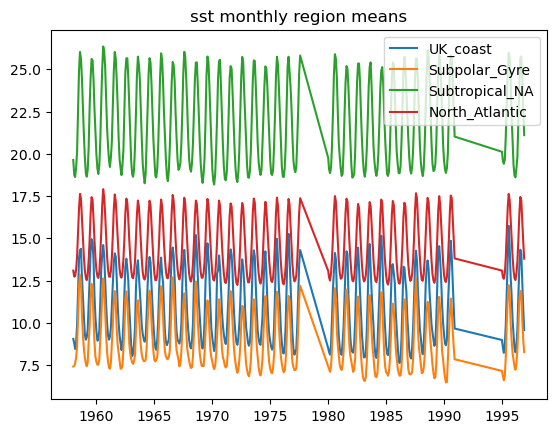

In [7]:
var = "sst"
dfv = df_monthly.query("variable == @var").set_index("time").sort_index()

plt.figure()
for col in REGION_NAMES:
    plt.plot(dfv.index, dfv[col], label=col)
plt.title(f"{var} monthly region means")
plt.legend()
plt.show()


I then define the slope and z-score:


In [8]:
def trend_metrics(s: pd.Series) -> dict:
    s = s.dropna()
    n = len(s)
    if n < 6:
        return dict(n=n, slope=np.nan, z_score=np.nan)

    y = s.to_numpy(dtype=float)
    t = np.arange(n)

    # Linear trend
    slope, intercept = np.polyfit(t, y, 1)
    total_trend = slope * (n - 1)

    # variability
    sigma = np.nanstd(y, ddof=1)
    if sigma < 1e-12:
        z = np.nan
    else:
        z = np.abs(total_trend) / sigma

    return dict(
        n=n,
        slope=slope,
        z_score=z,
    )


## 2. Ranking by Z-Score

Trends are first calculated on either a monthly, annual or seasonal basis and ranked by their z-scores. Naturally, the annual trends score highest due to their lower natural variablilty.

In [9]:
def aggregate_series(s: pd.Series, mode: str) -> pd.Series:
    s = s.sort_index()
    if mode == "monthly":
        return s.resample("MS").mean()
    if mode == "seasonal":
        return s.resample("QS-DEC").mean()
    if mode == "annual":
        return s.resample("YS").mean()
    raise ValueError(mode)


STEP_YEARS = {"monthly": 1/12, "seasonal": 1/4, "annual": 1.0}

modes = ["annual", "seasonal", "monthly"]
rows = []

for var in sorted(df_monthly["variable"].unique()):
    dfv = df_monthly.query("variable == @var").set_index("time").sort_index()

    for region in REGION_NAMES:
        s = dfv[region].dropna()

        for mode in modes:
            s_use = aggregate_series(s, mode)

            stats = trend_metrics(s_use)

            # convert slope from "per step" to "per year"
            slope_per_year = stats["slope"] / STEP_YEARS[mode] if np.isfinite(stats["slope"]) else np.nan

            rows.append({
                "variable": var,
                "region": region,
                "mode": mode,
                "t_start": s_use.index.min(),
                "t_end": s_use.index.max(),
                "n": stats["n"],
                "slope_per_step": stats["slope"],
                "slope_per_year": slope_per_year,
                "z_score": stats["z_score"],
            })

df_trends_basic = pd.DataFrame(rows)

# ranking by z-score strongest first
df_trends_basic = df_trends_basic.sort_values(["z_score", "n"], ascending=[False, False])

df_trends_basic.head(10)


,variable,region,mode,t_start,t_end,n,slope_per_step,slope_per_year,z_score
27,thetao,Subpolar_Gyre,annual,1958-01-01,1990-01-01,31,-0.026813,-0.026813,2.722287
3,salinity,Subpolar_Gyre,annual,1958-01-01,1977-01-01,20,-0.007997,-0.007997,2.697384
2,salinity,UK_coast,monthly,1958-01-01,1977-08-01,236,-0.000854,-0.010251,2.660072
1,salinity,UK_coast,seasonal,1957-12-01,1977-06-01,79,-0.002523,-0.010093,2.613621
0,salinity,UK_coast,annual,1958-01-01,1977-01-01,20,-0.010291,-0.010291,2.570713
4,salinity,Subpolar_Gyre,seasonal,1957-12-01,1977-06-01,79,-0.001995,-0.007980,2.462900
5,salinity,Subpolar_Gyre,monthly,1958-01-01,1977-08-01,236,-0.000674,-0.008092,2.448412
15,sst,Subpolar_Gyre,annual,1958-01-01,1996-01-01,33,-0.019596,-0.019596,2.106800
24,thetao,UK_coast,annual,1958-01-01,1990-01-01,31,-0.022136,-0.022136,2.076290
9,salinity,North_Atlantic,annual,1958-01-01,1977-01-01,20,-0.004403,-0.004403,1.924665


In addition to these I also look at more targeted time series:

- Same-month series (e.g. all Julys across different years)
- Same-season series (DJF, MAM, JJA, SON)

These approaches remove the seasonal cycle tp help  identify long term trends.

In [10]:
def month_subset_series(s: pd.Series, month: int) -> pd.Series:
    s = s.sort_index()
    return s[s.index.month == month]

def season_label(dt_index: pd.DatetimeIndex) -> pd.Series:
    """
    seasons DJF/MAM/JJA/SON.
    DJF is labelled by Jan/Feb year (Dec shifted to next year).
    """
    m = dt_index.month.to_numpy()
    y = dt_index.year.to_numpy()

    labels = np.empty(len(dt_index), dtype=object)
    season_year = y.copy()

    djf = (m == 12) | (m <= 2)
    labels[djf] = "DJF"
    season_year[m == 12] = y[m == 12] + 1

    mam = (m >= 3) & (m <= 5)
    labels[mam] = "MAM"

    jja = (m >= 6) & (m <= 8)
    labels[jja] = "JJA"

    son = (m >= 9) & (m <= 11)
    labels[son] = "SON"

    return pd.Series([f"{labels[i]}_{season_year[i]}" for i in range(len(dt_index))], index=dt_index)

def seasonal_mean_series(s: pd.Series) -> pd.Series:
    s = s.sort_index()
    key = season_label(s.index)
    grouped = s.groupby(key).mean()

    years = [int(k.split("_")[1]) for k in grouped.index]
    grouped.index = pd.to_datetime([f"{yy}-01-01" for yy in years])
    return grouped.sort_index()


I then calculate for every combination of region, time series, variable etc and put all the data into one dataframe ranked by z-score:

In [11]:
rows = []

for var in sorted(df_monthly["variable"].unique()):
    dfv = df_monthly.query("variable == @var").set_index("time").sort_index()

    for region in REGION_NAMES:
        s_all = dfv[region].dropna().sort_index()

        # all months (raw monthly series)
        s_use = s_all
        stats = trend_metrics(s_use)
        rows.append({
            "variable": var,
            "region": region,
            "comparison": "all_months",
            "subset": "ALL",
            "t_start": s_use.index.min(),
            "t_end": s_use.index.max(),
            "n": stats["n"],
            "slope_per_step": stats["slope"],           # per month-step
            "slope_per_year": stats["slope"] * 12 if np.isfinite(stats["slope"]) else np.nan,
            "z_score": stats["z_score"],
        })

        # same month across years (Jan-only, Feb-only, ...)
        for m in range(1, 13):
            s_use = month_subset_series(s_all, m)
            stats = trend_metrics(s_use)

            rows.append({
                "variable": var,
                "region": region,
                "comparison": "same_month",
                "subset": pd.Timestamp(2000, m, 1).strftime("%b"),
                "t_start": s_use.index.min() if len(s_use) else pd.NaT,
                "t_end": s_use.index.max() if len(s_use) else pd.NaT,
                "n": stats["n"],
                "slope_per_step": stats["slope"],       # per year-step (since one point per year)
                "slope_per_year": stats["slope"],       # already per year-step
                "z_score": stats["z_score"],
            })

        # same season across years (DJF/MAM/JJA/SON)
        season_masks = {
            "DJF": ((s_all.index.month == 12) | (s_all.index.month <= 2)),
            "MAM": ((s_all.index.month >= 3) & (s_all.index.month <= 5)),
            "JJA": ((s_all.index.month >= 6) & (s_all.index.month <= 8)),
            "SON": ((s_all.index.month >= 9) & (s_all.index.month <= 11)),
        }

        for season_name, mask in season_masks.items():
            s_months = s_all[mask]
            s_use = seasonal_mean_series(s_months)  # one point per year (for that season)
            stats = trend_metrics(s_use)

            rows.append({
                "variable": var,
                "region": region,
                "comparison": "same_season",
                "subset": season_name,
                "t_start": s_use.index.min() if len(s_use) else pd.NaT,
                "t_end": s_use.index.max() if len(s_use) else pd.NaT,
                "n": stats["n"],
                "slope_per_step": stats["slope"],       # per year-step
                "slope_per_year": stats["slope"],       # per year-step
                "z_score": stats["z_score"],
            })

df_trends_subsets = pd.DataFrame(rows)

# rank by z-score (strongest) then by n
df_trends_subsets = df_trends_subsets.sort_values(["z_score", "n"], ascending=[False, False])

df_trends_subsets.head(20)


,variable,region,comparison,subset,t_start,t_end,n,slope_per_step,slope_per_year,z_score
25,salinity,Subpolar_Gyre,same_month,Aug,1958-08-01,1977-08-01,20,-0.010947,-0.010947,2.858762
167,thetao,Subpolar_Gyre,same_season,MAM,1958-01-01,1990-01-01,31,-0.032538,-0.032538,2.828135
26,salinity,Subpolar_Gyre,same_month,Sep,1958-09-01,1976-09-01,19,-0.010947,-0.010947,2.822649
27,salinity,Subpolar_Gyre,same_month,Oct,1958-10-01,1976-10-01,19,-0.011166,-0.011166,2.798059
33,salinity,Subpolar_Gyre,same_season,SON,1958-01-01,1976-01-01,19,-0.010913,-0.010913,2.796502
158,thetao,Subpolar_Gyre,same_month,May,1958-05-01,1990-05-01,31,-0.033566,-0.033566,2.795691
157,thetao,Subpolar_Gyre,same_month,Apr,1958-04-01,1990-04-01,31,-0.033498,-0.033498,2.787234
32,salinity,Subpolar_Gyre,same_season,JJA,1958-01-01,1977-01-01,20,-0.009390,-0.009390,2.777013
24,salinity,Subpolar_Gyre,same_month,Jul,1958-07-01,1977-07-01,20,-0.009395,-0.009395,2.764261
29,salinity,Subpolar_Gyre,same_month,Dec,1958-12-01,1976-12-01,19,-0.009391,-0.009391,2.725214


I then plot the top 10:

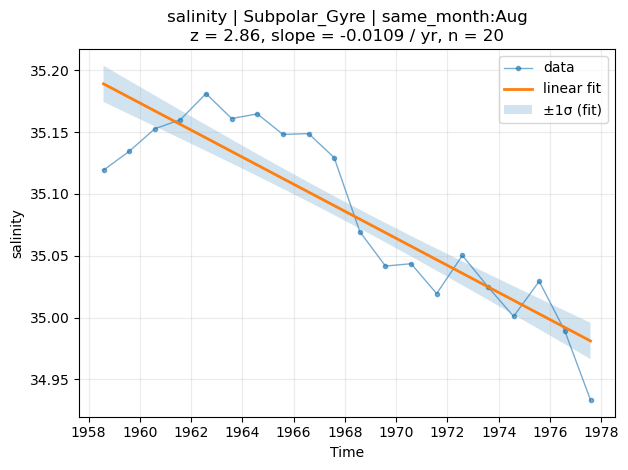

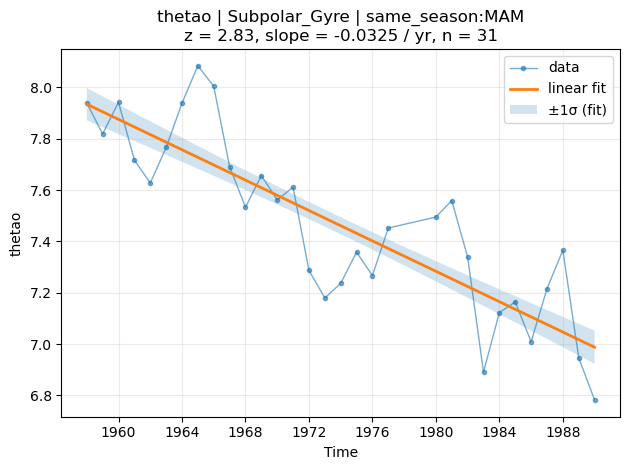

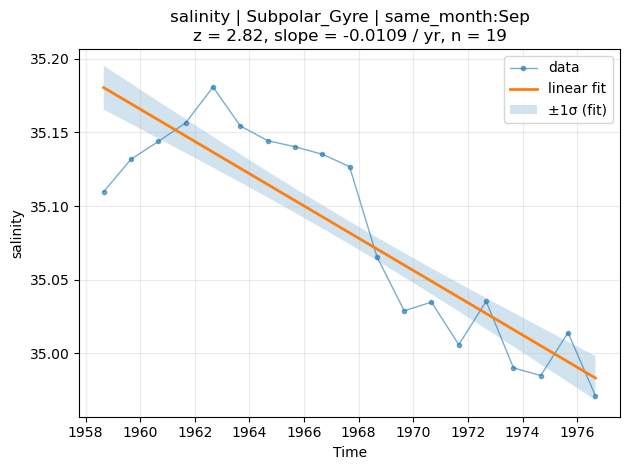

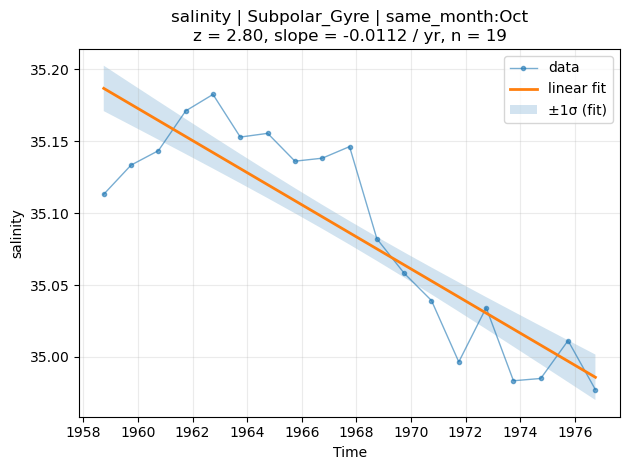

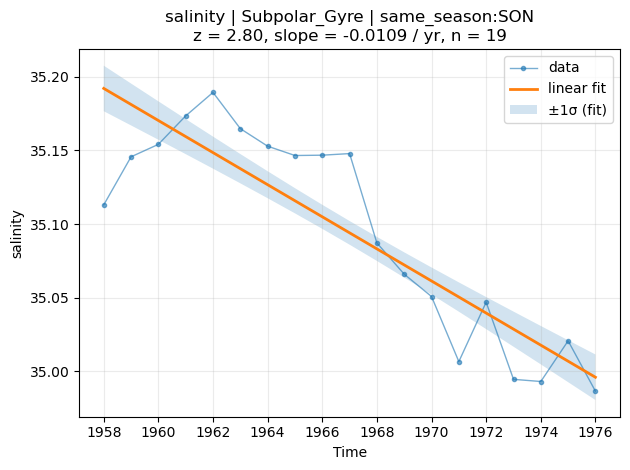

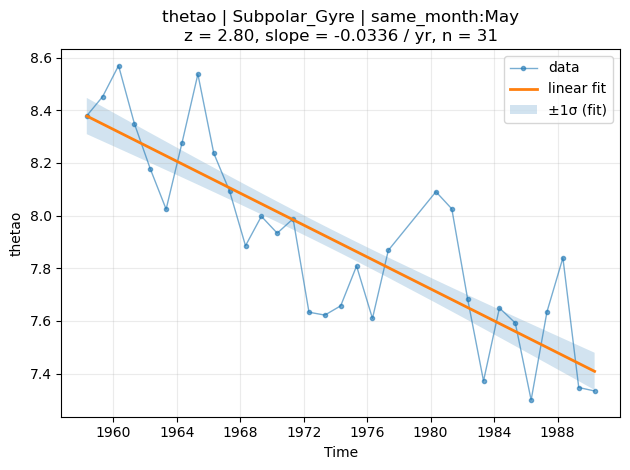

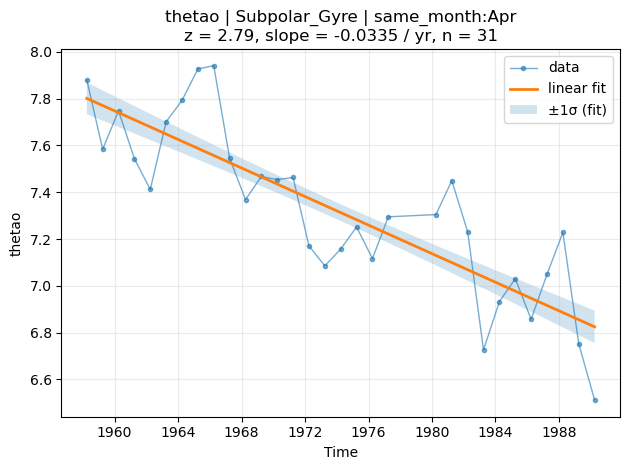

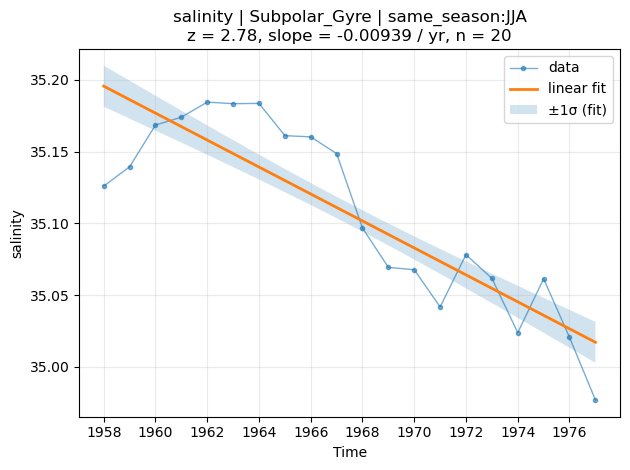

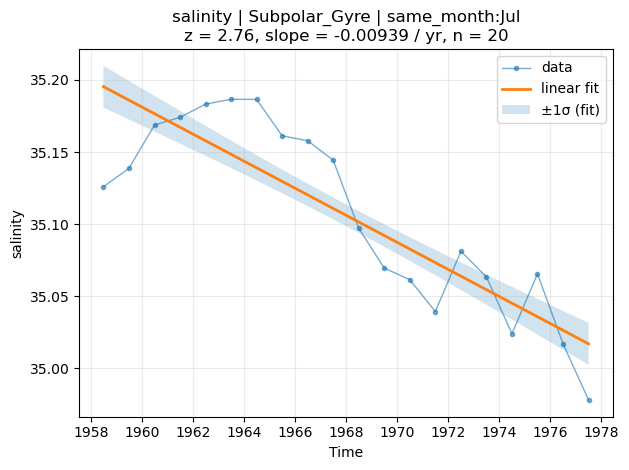

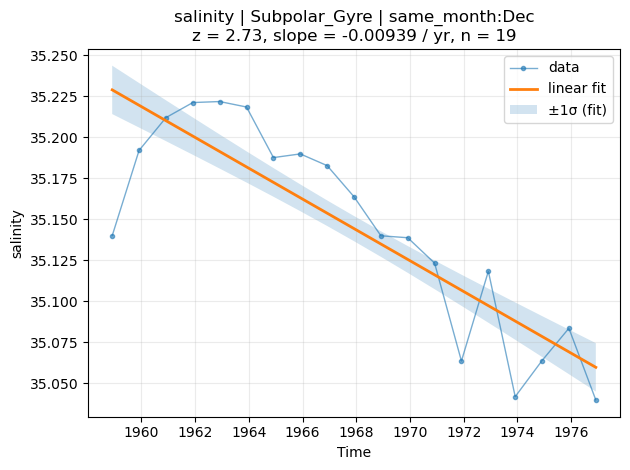

In [12]:
# Select top 10 strongest trends by z-score
top = (
    df_trends_subsets
    .dropna(subset=["z_score"])
    .sort_values(["z_score", "n"], ascending=[False, False])
    .head(10)
)

for _, row in top.iterrows():
    var = row["variable"]
    region = row["region"]
    comp = row["comparison"]
    subset = row["subset"]

    # Base monthly series
    s_all = (
        df_monthly
        .query("variable == @var")
        .set_index("time")
        .sort_index()[region]
        .dropna()
    )

    # Reconstruct the plotted series
    if comp == "all_months":
        s_plot = s_all

    elif comp == "same_month":
        month_num = pd.to_datetime(subset, format="%b").month
        s_plot = month_subset_series(s_all, month_num)

    elif comp == "same_season":
        m = s_all.index.month
        if subset == "DJF":
            s_plot = seasonal_mean_series(s_all[(m == 12) | (m <= 2)])
        elif subset == "MAM":
            s_plot = seasonal_mean_series(s_all[(m >= 3) & (m <= 5)])
        elif subset == "JJA":
            s_plot = seasonal_mean_series(s_all[(m >= 6) & (m <= 8)])
        elif subset == "SON":
            s_plot = seasonal_mean_series(s_all[(m >= 9) & (m <= 11)])
        else:
            raise ValueError(subset)

    else:
        raise ValueError(comp)

    # Linear fit + 1sigma band
    s_plot = s_plot.dropna().sort_index()
    x_time = s_plot.index
    y = s_plot.values.astype(float)

    # numeric time in years since start
    t = (x_time - x_time[0]).days / 365.25

    # fit y = a + b t
    b, a = np.polyfit(t, y, 1)
    y_hat = a + b * t

    # 1sigma band for the fitted mean
    n = len(y)
    if n >= 3:
        resid = y - y_hat
        s = np.sqrt(np.sum(resid**2) / (n - 2))
        tbar = np.mean(t)
        Sxx = np.sum((t - tbar)**2)

        if Sxx > 0:
            se_fit = s * np.sqrt((1 / n) + ((t - tbar) ** 2) / Sxx)
        else:
            se_fit = np.full_like(t, np.nan)
    else:
        se_fit = np.full_like(t, np.nan)

    # Plot
    plt.figure()
    plt.plot(
        x_time, y,
        linestyle="-",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label="data"
    )

    plt.plot(x_time, y_hat, linewidth=2, label="linear fit")

    # band
    if np.isfinite(se_fit).any():
        plt.fill_between(x_time, y_hat - se_fit, y_hat + se_fit, alpha=0.2, label="±1σ (fit)")

    plt.title(
        f"{var} | {region} | {comp}:{subset}\n"
        f"z = {row['z_score']:.2f}, slope = {row['slope_per_year']:.3g} / yr, n = {int(row['n'])}"
    )
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


Processing: salinity | Subpolar_Gyre


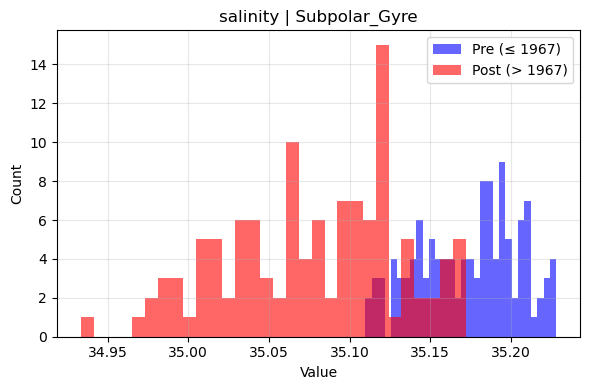

Processing: thetao | Subpolar_Gyre


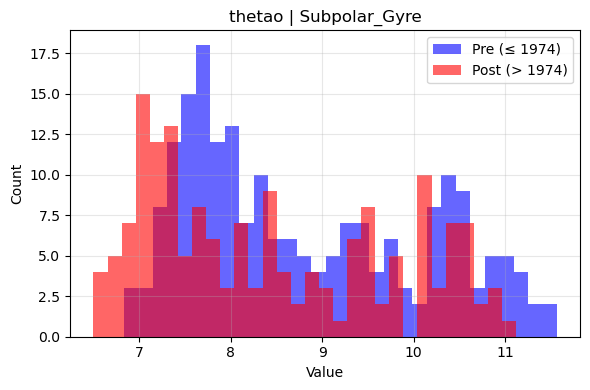

Processing: salinity | Subpolar_Gyre


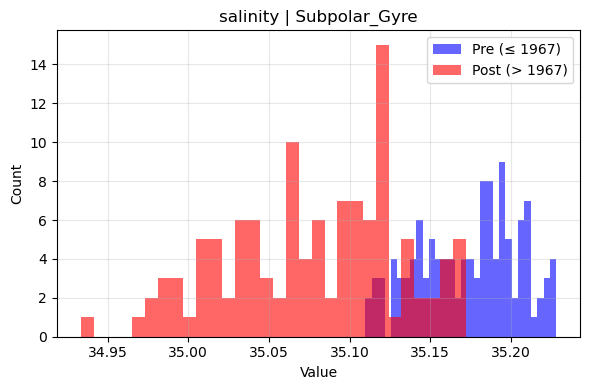

Processing: salinity | Subpolar_Gyre


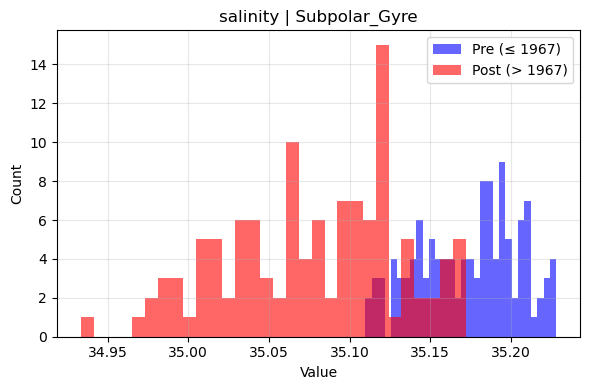

Processing: salinity | Subpolar_Gyre


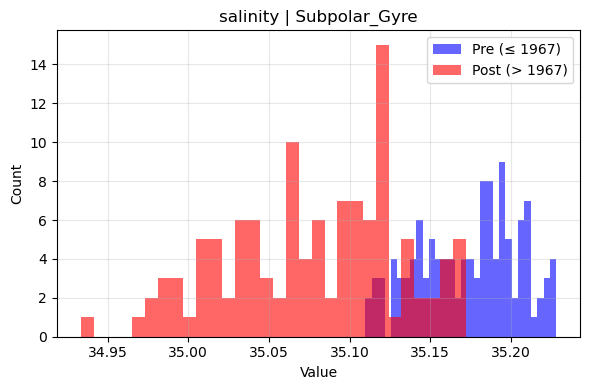

Processing: thetao | Subpolar_Gyre


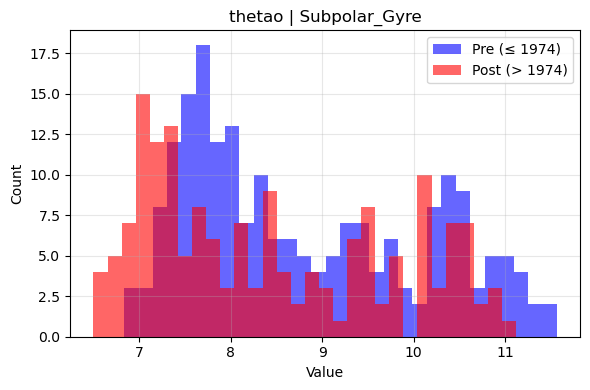

Processing: thetao | Subpolar_Gyre


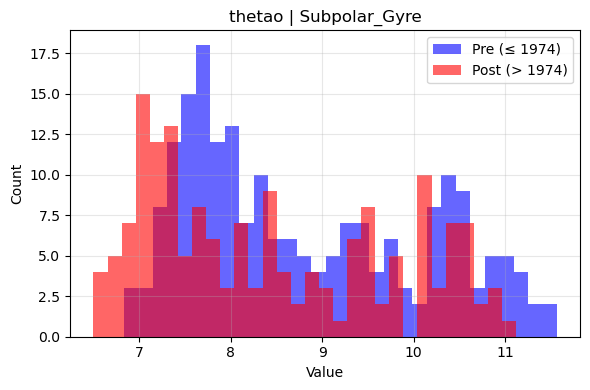

Processing: salinity | Subpolar_Gyre


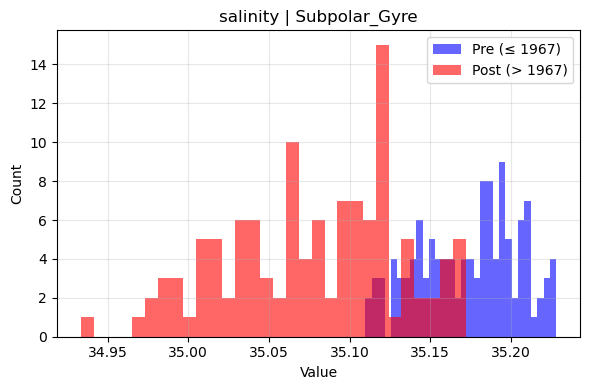

Processing: salinity | Subpolar_Gyre


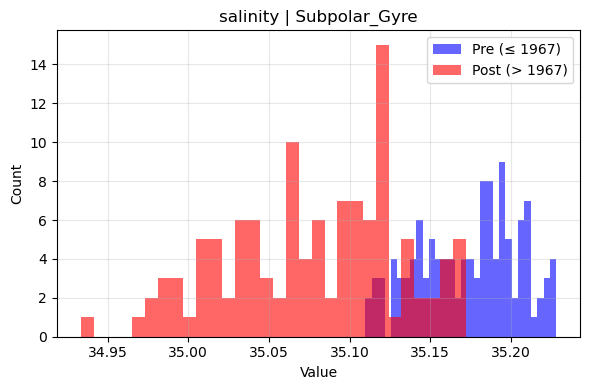

Processing: salinity | Subpolar_Gyre


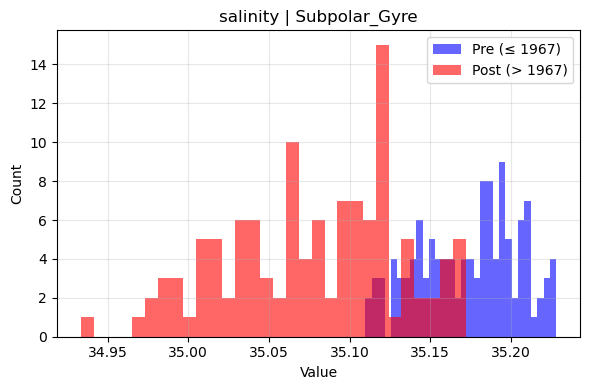

In [13]:
# Histograms: 1 month = one count (avg over give spatial area for that month)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Rank by z_score
top10 = df_trends_subsets.sort_values("z_score", ascending=False).head(10)

for _, row in top10.iterrows():

    var = row["variable"]
    region = row["region"]

    print(f"Processing: {var} | {region}")

    # Extract series for variable + region
    df_var = df_monthly.query("variable == @var").copy()
    df_var = df_var.sort_values("time")

    years = pd.to_datetime(df_var["time"]).dt.year
    mid_year = int(years.min() + (years.max() - years.min()) / 2)

    # Pre/Post split
    pre_vals = df_var.loc[years <= mid_year, region].dropna().values
    post_vals = df_var.loc[years > mid_year, region].dropna().values

    # Plot
    plt.figure(figsize=(6,4))
    plt.hist(pre_vals, bins=30, alpha=0.6, color="blue", label=f"Pre (≤ {mid_year})")
    plt.hist(post_vals, bins=30, alpha=0.6, color="red", label=f"Post (> {mid_year})")
    plt.title(f"{var} | {region}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Processing: salinity | Subpolar_Gyre | same_month | Aug


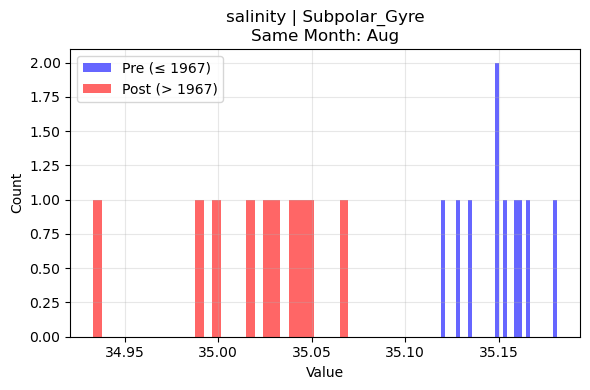

Processing: thetao | Subpolar_Gyre | same_season | MAM


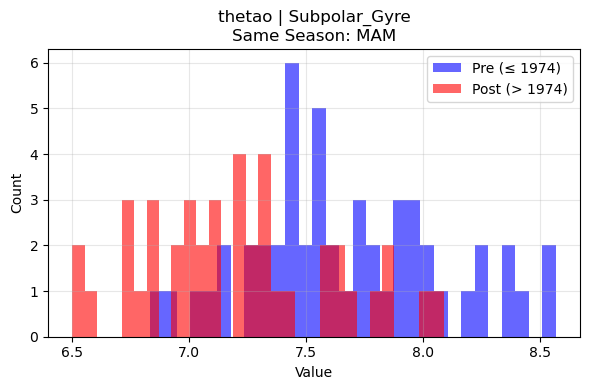

Processing: salinity | Subpolar_Gyre | same_month | Sep


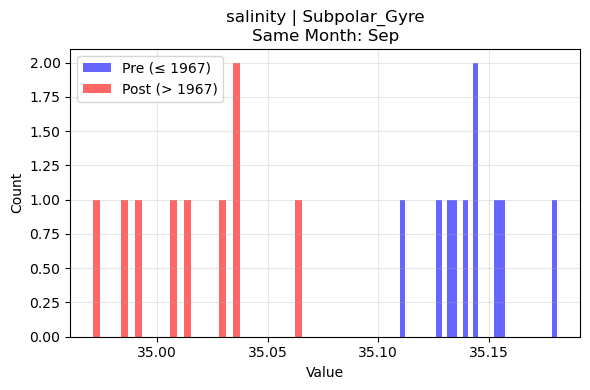

Processing: salinity | Subpolar_Gyre | same_month | Oct


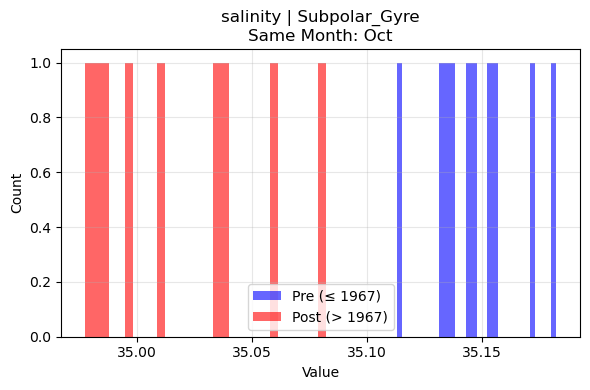

Processing: salinity | Subpolar_Gyre | same_season | SON


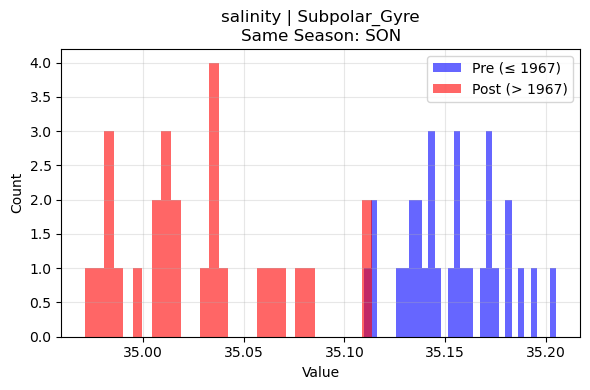

Processing: thetao | Subpolar_Gyre | same_month | May


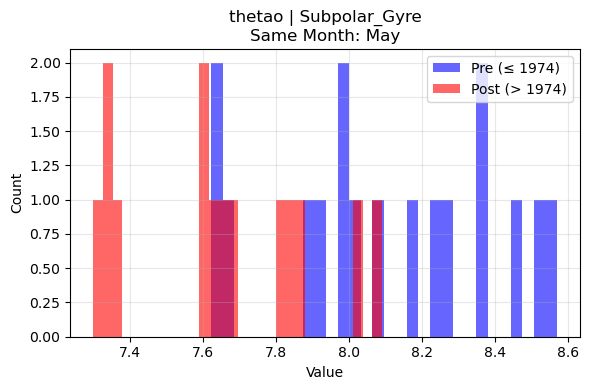

Processing: thetao | Subpolar_Gyre | same_month | Apr


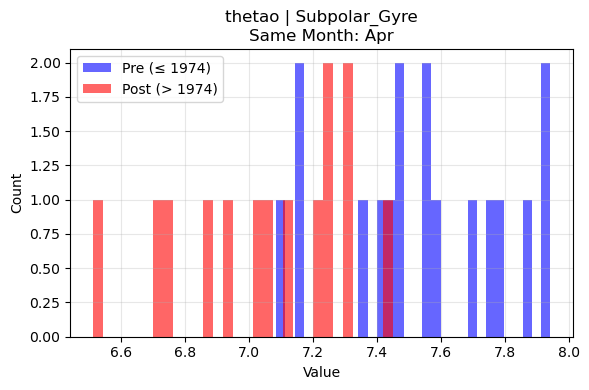

Processing: salinity | Subpolar_Gyre | same_season | JJA


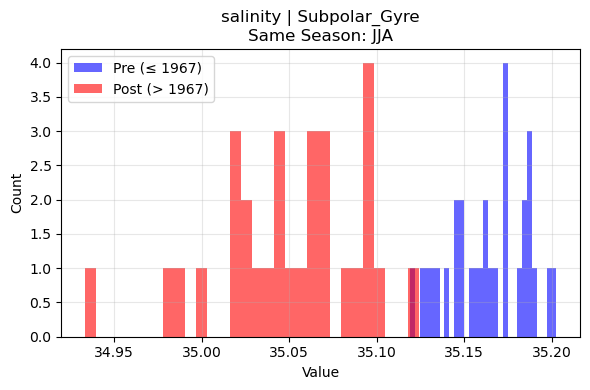

Processing: salinity | Subpolar_Gyre | same_month | Jul


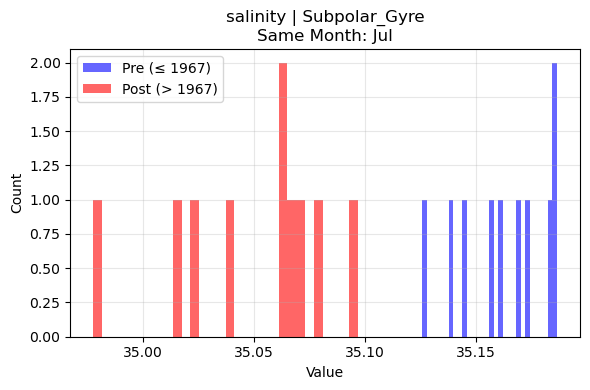

Processing: salinity | Subpolar_Gyre | same_month | Dec


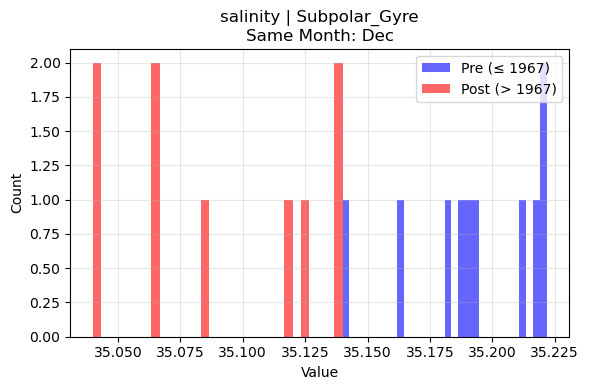

In [14]:
# Histograms: 1 month or season = one count (avg over give spatial area for that month/season)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

top10 = df_trends_subsets.sort_values("z_score", ascending=False).head(10)

for _, row in top10.iterrows():

    var = row["variable"]
    region = row["region"]
    comparison = row["comparison"]
    subset = row["subset"]

    print(f"Processing: {var} | {region} | {comparison} | {subset}")

    df_var = df_monthly.query("variable == @var").copy()
    df_var = df_var.sort_values("time")

    years = pd.to_datetime(df_var["time"]).dt.year
    mid_year = int(years.min() + (years.max() - years.min()) / 2)

    # Apply subset logic
    if comparison == "all_months":
        df_subset = df_var

    elif comparison == "same_month":
        month_num = pd.to_datetime(subset, format="%b").month
        df_subset = df_var[pd.to_datetime(df_var["time"]).dt.month == month_num]

    elif comparison == "same_season":
        months = pd.to_datetime(df_var["time"]).dt.month

        if subset == "DJF":
            df_subset = df_var[(months == 12) | (months <= 2)]
        elif subset == "MAM":
            df_subset = df_var[(months >= 3) & (months <= 5)]
        elif subset == "JJA":
            df_subset = df_var[(months >= 6) & (months <= 8)]
        elif subset == "SON":
            df_subset = df_var[(months >= 9) & (months <= 11)]

    # Pre/Post split
    years_subset = pd.to_datetime(df_subset["time"]).dt.year
    pre_vals = df_subset.loc[years_subset <= mid_year, region].dropna().values
    post_vals = df_subset.loc[years_subset > mid_year, region].dropna().values

    # Title Label
    if comparison == "all_months":
        label_text = "All Months"
    elif comparison == "same_month":
        label_text = f"Same Month: {subset}"
    elif comparison == "same_season":
        label_text = f"Same Season: {subset}"

    # Plot
    plt.figure(figsize=(6,4))
    plt.hist(pre_vals, bins=30, alpha=0.6, color="blue", label=f"Pre (≤ {mid_year})")
    plt.hist(post_vals, bins=30, alpha=0.6, color="red", label=f"Post (> {mid_year})")

    plt.title(f"{var} | {region}\n{label_text}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



Processing token: sst  (files: 392)


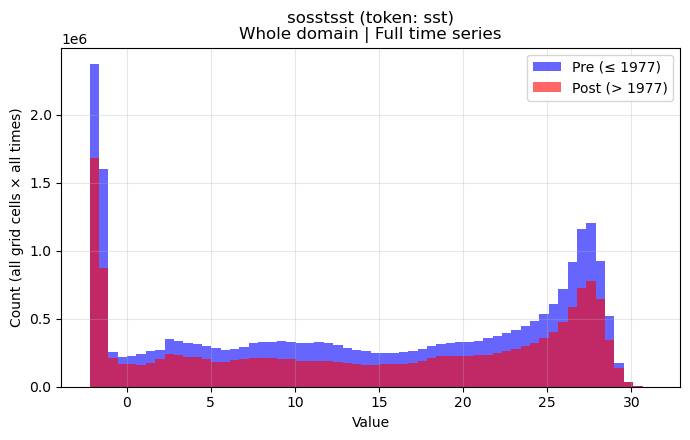


Processing token: salinity  (files: 236)


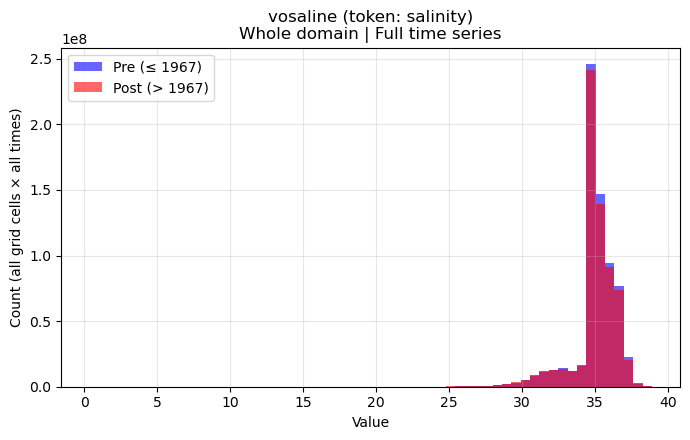


Processing token: u  (files: 876)


In [ ]:
# One count = 1 grid cell

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import xarray as xr

data_dir = Path(DATA_DIR)

def files_for_token(token: str):
    all_nc = list(data_dir.rglob("*.nc"))
    try:
        return sorted([p for p in all_nc if FILE_RE.search(p.name) and (token in p.name)])
    except Exception:
        return sorted([p for p in all_nc if token in p.name])

def get_year(ds, path: Path):
    # try common time coordinate names
    for tname in ["time", "time_counter", "t", "TIME", "nav_time"]:
        if tname in ds.coords:
            t = pd.to_datetime(np.asarray(ds[tname].values).ravel()[0])
            return int(t.year)
        if tname in ds.variables:
            # sometimes stored as a data variable, not coord
            try:
                t = pd.to_datetime(np.asarray(ds[tname].values).ravel()[0])
                return int(t.year)
            except Exception:
                pass

    # fall back to the notebook helper that parses from filename
    if "time_from_name" in globals():
        t = time_from_name(path.name)
        t = pd.to_datetime(t)
        return int(t.year)

    raise ValueError(f"Could not infer year for file: {path.name}")

NBINS = 60

for token in VARIABLE_TOKENS:
    paths = files_for_token(token)
    if not paths:
        print(f"[SKIP] No files found for token: {token}")
        continue

    print(f"\nProcessing token: {token}  (files: {len(paths)})")

    # determine midyear + global min/max for bins
    years_all = []
    vmin, vmax = np.inf, -np.inf
    var_name_global = None

    for p in paths:
        with xr.open_dataset(p, decode_times=True) as ds0:
            var_name = infer_data_var(ds0) if "infer_data_var" in globals() else list(ds0.data_vars)[0]
            if var_name_global is None:
                var_name_global = var_name

            y = get_year(ds0, p)
            years_all.append(y)

            arr = np.asarray(ds0[var_name].values).ravel()
            arr = arr[~np.isnan(arr)]
            if arr.size:
                vmin = min(vmin, float(arr.min()))
                vmax = max(vmax, float(arr.max()))

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        print(f"[SKIP] Could not determine range for {token} (all NaNs or constant).")
        continue

    y_min, y_max = int(np.min(years_all)), int(np.max(years_all))
    mid_year = int(y_min + (y_max - y_min) / 2)

    bins = np.linspace(vmin, vmax, NBINS + 1)

    # accumulate histograms without combining datasets
    counts_pre = np.zeros(NBINS, dtype=np.int64)
    counts_post = np.zeros(NBINS, dtype=np.int64)

    for p in paths:
        with xr.open_dataset(p, decode_times=True) as ds0:
            var_name = infer_data_var(ds0) if "infer_data_var" in globals() else list(ds0.data_vars)[0]
            y = get_year(ds0, p)

            arr = np.asarray(ds0[var_name].values).ravel()
            arr = arr[~np.isnan(arr)]
            if not arr.size:
                continue

            h, _ = np.histogram(arr, bins=bins)
            if y <= mid_year:
                counts_pre += h
            else:
                counts_post += h

    # Plot from binned counts
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_widths = np.diff(bins)

    plt.figure(figsize=(7, 4.5))
    plt.bar(bin_centers, counts_pre,  width=bin_widths, alpha=0.6, color="blue", label=f"Pre (≤ {mid_year})", align="center")
    plt.bar(bin_centers, counts_post, width=bin_widths, alpha=0.6, color="red",  label=f"Post (> {mid_year})", align="center")

    plt.title(f"{var_name_global} (token: {token})\nWhole domain | Full time series")
    plt.xlabel("Value")
    plt.ylabel("Count (all grid cells × all times)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
